#Regresi untuk Prediksi Numerik pada Data Teknik Industri

Sesi ini membahas penerapan machine learning terawasi untuk masalah prediksi numerik melalui pendekatan regresi. Dalam konteks data science, regresi digunakan ketika variabel target berbentuk angka kontinu, misalnya output produksi, lead time, konsumsi energi, atau permintaan.

Notebook ini dirancang untuk memperkenalkan alur kerja pemodelan secara sistematis: memahami variabel target, memilih fitur, membagi data latih dan data uji, melatih model, melakukan prediksi, dan mengevaluasi performa model menggunakan metrik error yang mudah diinterpretasikan secara operasional.

## 1. LandasanApa Itu Regresi?

Regresi merupakan metode supervised learning yang digunakan ketika target yang ingin diprediksi berupa nilai numerik. Model regresi mempelajari hubungan antara sejumlah variabel input (fitur) dengan satu variabel output (target), kemudian menggunakan pola tersebut untuk memperkirakan nilai baru.

Dalam konteks teknik industri, regresi relevan untuk memprediksi output produksi, waktu proses, kebutuhan persediaan, konsumsi energi, dan indikator kuantitatif lainnya. Regresi linear dipilih pada tahap awal pembelajaran karena struktur matematisnya sederhana dan hasilnya relatif mudah diinterpretasikan.

## 3. Deskripsi Dataset dan Penentuan Masalah

Dataset merepresentasikan data produksi per shift dengan beberapa variabel operasional, seperti downtime, defect, jumlah operator, suhu mesin, dan target produksi. Pada sesi ini, variabel **Output_Unit** akan digunakan sebagai target prediksi numerik.

Secara konseptual, model akan mempelajari bagaimana perubahan kondisi operasional berasosiasi dengan jumlah output yang dihasilkan.

In [ ]:
# [CODEBLOCK]
# =============================================================================
# IMPOR LIBRARY YANG DIPERLUKAN
# =============================================================================
# pandas: manipulasi data
# matplotlib: visualisasi
# train_test_split: membagi data latih dan data uji
# LinearRegression: model regresi linear
# mean_absolute_error, mean_squared_error, r2_score: evaluasi model

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library untuk regresi siap digunakan')

Library untuk regresi siap digunakan


In [ ]:
# [CODEBLOCK]
# =============================================================================
# MEMBUAT DATAFRAME DARI VARIABEL PYTHON
# =============================================================================
# Data didefinisikan langsung agar mahasiswa dapat memodifikasi nilai
# tanpa perlu mengakses file eksternal.

data = {
    'Tanggal': [
        '2026-01-05','2026-01-05','2026-01-06','2026-01-06',
        '2026-01-07','2026-01-07','2026-01-08','2026-01-08',
        '2026-01-09','2026-01-09','2026-01-10','2026-01-10',
        '2026-01-11','2026-01-11','2026-01-12','2026-01-12'
    ],
    'Shift': [
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang'
    ],
    'Mesin': [
        'M1','M1','M1','M1',
        'M2','M2','M2','M2',
        'M1','M1','M2','M2',
        'M1','M1','M2','M2'
    ],
    'Downtime_Menit': [
        30,35,25,28,40,42,20,22,15,18,24,26,33,36,19,21
    ],
    'Defect_Unit': [
        5,6,4,5,6,7,3,4,2,3,4,4,5,6,3,3
    ],
    'Operator_Hadir': [
        8,8,8,8,7,7,8,8,8,8,7,7,8,8,8,8
    ],
    'Suhu_Mesin': [
        72,74,70,71,79,81,69,70,67,68,73,75,76,77,68,69
    ],
    'Target_Unit': [
        130,130,130,130,130,130,135,135,140,140,138,138,132,132,140,140
    ],
    'Output_Unit': [
        120,118,135,132,128,125,140,138,150,146,142,139,131,129,147,145
    ]
}

df = pd.DataFrame(data)
df.head()

,Tanggal,Shift,Mesin,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Target_Unit,Output_Unit
0,2026-01-05,Pagi,M1,30,5,8,72,130,120
1,2026-01-05,Siang,M1,35,6,8,74,130,118
2,2026-01-06,Pagi,M1,25,4,8,70,130,135
3,2026-01-06,Siang,M1,28,5,8,71,130,132
4,2026-01-07,Pagi,M2,40,6,7,79,130,128


## 4. Menentukan Fitur dan Target

Dalam supervised learning, variabel target adalah nilai yang ingin diprediksi. Variabel lain yang digunakan untuk membantu prediksi disebut fitur. Pada sesi ini:

- **Target**: `Output_Unit`
- **Fitur**: `Downtime_Menit`, `Defect_Unit`, `Operator_Hadir`, `Suhu_Mesin`, `Target_Unit`

Pemilihan fitur ini didasarkan pada relevansi operasional terhadap jumlah output yang dihasilkan.

In [ ]:
# [CODEBLOCK]
# =============================================================================
# MEMISAHKAN FITUR (X) DAN TARGET (y)
# =============================================================================
# X berisi variabel input yang akan digunakan model
# y berisi variabel target yang ingin diprediksi

X = df[['Downtime_Menit', 'Defect_Unit', 'Operator_Hadir', 'Suhu_Mesin', 'Target_Unit']]
y = df['Output_Unit']

print('Bentuk data fitur:', X.shape)
print('Bentuk data target:', y.shape)

Bentuk data fitur: (16, 5)
Bentuk data target: (16,)


## 5. Train-Test Split

Salah satu prinsip penting dalam machine learning adalah memisahkan data menjadi data latih dan data uji. Data latih digunakan untuk membangun model, sedangkan data uji digunakan untuk mengevaluasi performa model pada data yang tidak digunakan saat pelatihan.

Pembagian ini penting agar evaluasi model lebih objektif.

In [ ]:
# =============================================================================
# MEMBAGI DATA MENJADI TRAINING SET DAN TESTING SET
# =============================================================================
# test_size=0.25 berarti 25% data digunakan untuk pengujian
# random_state=42 digunakan agar hasil pembagian konsisten

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji:', X_test.shape[0])

Jumlah data latih: 12
Jumlah data uji: 4


## 6. Membangun Model Regresi Linear

Model regresi linear mempelajari hubungan linier antara fitur dan target. Secara sederhana, model akan mencari kombinasi koefisien terbaik yang meminimalkan selisih antara nilai aktual dan nilai prediksi.

In [ ]:
# =============================================================================
# MEMBANGUN DAN MELATIH MODEL REGRESI LINEAR
# =============================================================================
# LinearRegression() membuat objek model
# fit() melatih model menggunakan data latih

model = LinearRegression()
model.fit(X_train, y_train)

print('Model regresi linear berhasil dilatih')

Model regresi linear berhasil dilatih


## 7. Melakukan Prediksi

Setelah model dilatih, langkah berikutnya adalah menghasilkan prediksi pada data uji. Prediksi ini kemudian dibandingkan dengan nilai aktual untuk menilai seberapa baik model bekerja.

In [ ]:
# =============================================================================
# MENGHASILKAN PREDIKSI PADA DATA UJI
# =============================================================================
# predict() menghasilkan nilai prediksi berdasarkan fitur pada X_test

y_pred = model.predict(X_test)

# Menampilkan perbandingan aktual vs prediksi
hasil_prediksi = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

hasil_prediksi

,Aktual,Prediksi
0,120,131.782789
1,118,128.952693
2,125,124.427223
3,147,146.239933


## 8. Evaluasi Model: MAE, RMSE, dan R²

Evaluasi model regresi dapat dilakukan dengan beberapa metrik utama:

- **MAE (Mean Absolute Error)**: rata-rata kesalahan absolut.
- **RMSE (Root Mean Squared Error)**: kesalahan rata-rata dengan penalti lebih besar untuk error besar.
- **R² (Coefficient of Determination)**: proporsi variasi target yang dapat dijelaskan model.

Dalam konteks pembelajaran awal, MAE dan RMSE lebih mudah dijelaskan karena keduanya masih berada dalam satuan yang sama dengan target prediksi.

In [ ]:
# =============================================================================
# MENGHITUNG METRIK EVALUASI MODEL
# =============================================================================
# mean_absolute_error: rata-rata selisih absolut
# mean_squared_error: rata-rata kuadrat selisih
# RMSE diperoleh dengan akar dari MSE
# r2_score: seberapa baik model menjelaskan variasi data

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('MAE :', mae)
print('RMSE:', rmse)
print('R²  :', r2)

MAE : 6.017081649739723
RMSE: 8.05762659897796
R²  : 0.5127553740445995


## 9. Visualisasi Aktual vs Prediksi

Visualisasi membantu kita memahami apakah prediksi model sudah mendekati nilai aktual. Jika titik-titik prediksi berada dekat dengan garis diagonal ideal, maka model cenderung memiliki performa yang baik.

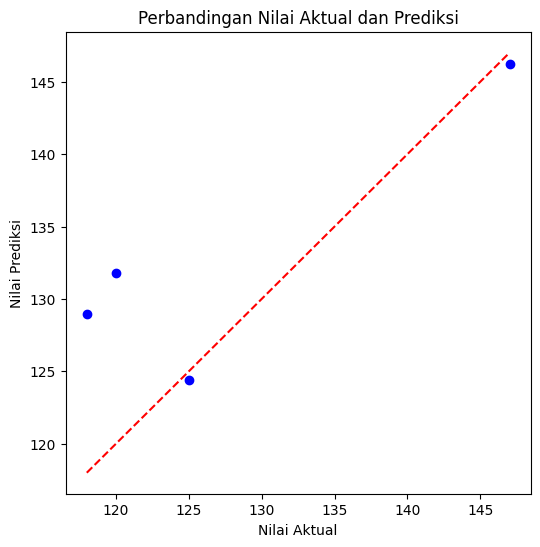

In [ ]:
# =============================================================================
# VISUALISASI NILAI AKTUAL DAN PREDIKSI
# =============================================================================
# Scatter plot digunakan untuk membandingkan y_test dan y_pred
# Garis merah putus-putus menunjukkan kondisi ideal (prediksi = aktual)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Perbandingan Nilai Aktual dan Prediksi')
plt.show()

## 10. Koefisien Model

Salah satu kelebihan regresi linear adalah model ini relatif mudah diinterpretasikan. Setiap fitur memiliki koefisien yang menunjukkan arah pengaruh terhadap target.

- Koefisien positif menunjukkan hubungan searah.
- Koefisien negatif menunjukkan hubungan berlawanan arah.

Interpretasi ini harus dilakukan dengan hati-hati dan tetap mempertimbangkan konteks data.

In [ ]:
# =============================================================================
# MENAMPILKAN KOEFISIEN MODEL
# =============================================================================
# Setiap koefisien menunjukkan kontribusi relatif fitur terhadap prediksi target

koefisien = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
})

koefisien

,Fitur,Koefisien
0,Downtime_Menit,0.234072
1,Defect_Unit,-2.308362
2,Operator_Hadir,-2.066716
3,Suhu_Mesin,-0.846047
4,Target_Unit,0.903102
